In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
vehiclesdf_unclean = pd.read_csv("vehicles.csv")

vehiclesdfc = vehiclesdf_unclean[["id","region","region_url","price","year","manufacturer","model","condition","cylinders","state","posting_date"]]
vehiclesdfc.head()

,id,region,region_url,price,year,manufacturer,model,condition,cylinders,state,posting_date
0,7222695916,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,az,NaN
1,7218891961,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,7221797935,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,7222270760,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,7210384030,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [4]:
print(vehiclesdfc.shape)
print(" ")
print(vehiclesdfc.info())
print(vehiclesdfc.describe())
print((vehiclesdfc.isnull().sum() / len(vehiclesdfc)) * 100)

(426880, 11)
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   region_url    426880 non-null  object 
 3   price         426880 non-null  int64  
 4   year          425675 non-null  float64
 5   manufacturer  409234 non-null  object 
 6   model         421603 non-null  object 
 7   condition     252776 non-null  object 
 8   cylinders     249202 non-null  object 
 9   state         426880 non-null  object 
 10  posting_date  426812 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 35.8+ MB
None
                 id         price           year
count  4.268800e+05  4.268800e+05  425675.000000
mean   7.311487e+09  7.519903e+04    2011.235191
std    4.473170e+06  1.218228e+07       9.452120
min    7.207408e+09  0.000000e+00    1

In [5]:
# Due to condition and cylinders being at 40% with nAN values then we should drop it
vehiclesdfc = vehiclesdfc.drop(columns=["condition", "cylinders"])
vehiclesdfc = vehiclesdfc.dropna()
vehiclesdfc_clean = vehiclesdfc.copy()

In [6]:
vehiclesdfc_clean.head()

,id,region,region_url,price,year,manufacturer,model,state,posting_date
27,7316814884,auburn,https://auburn.craigslist.org,33590,2014.0,gmc,sierra 1500 crew cab slt,al,2021-05-04T12:31:18-0500
28,7316814758,auburn,https://auburn.craigslist.org,22590,2010.0,chevrolet,silverado 1500,al,2021-05-04T12:31:08-0500
29,7316814989,auburn,https://auburn.craigslist.org,39590,2020.0,chevrolet,silverado 1500 crew,al,2021-05-04T12:31:25-0500
30,7316743432,auburn,https://auburn.craigslist.org,30990,2017.0,toyota,tundra double cab sr,al,2021-05-04T10:41:31-0500
31,7316356412,auburn,https://auburn.craigslist.org,15000,2013.0,ford,f-150 xlt,al,2021-05-03T14:02:03-0500


# Ana Model

In [7]:
# Ana uses: LinearRegression, Ridge, DecisionTreeRegressor, mean_squared_error, train_test_split

In [8]:
vehiclesdfc = vehiclesdfc_clean.copy()

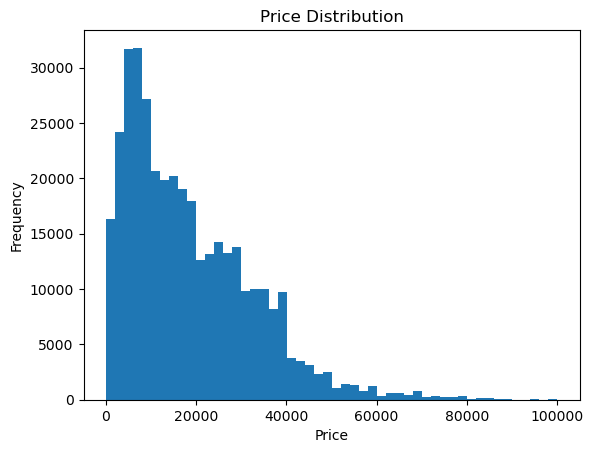

In [9]:
# clean out bad price values FIRST
vehiclesdfc = vehiclesdfc[vehiclesdfc['price'] > 100]
vehiclesdfc = vehiclesdfc[vehiclesdfc['price'] < 100000]

# THEN plot
plt.hist(vehiclesdfc['price'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [10]:
# selecting features for modeling
df_model = vehiclesdfc[['price', 'year']]
df_model = df_model.dropna()

In [11]:
# X = features, y = target
X = df_model[['year']]
y = df_model['price']

In [12]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# Model 1: Linear Regression
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)

mse1 = mean_squared_error(y_test, y_pred1)
print("Linear Regression MSE:", mse1)

Linear Regression MSE: 173506510.83536044


In [14]:
# Model 2: Decision Tree
model2 = DecisionTreeRegressor(max_depth=5)
model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

mse2 = mean_squared_error(y_test, y_pred2)
print("Decision Tree MSE:", mse2)

Decision Tree MSE: 121691352.05825746


In [15]:
# Model 3: Ridge Regression
model3 = Ridge(alpha=1.0)
model3.fit(X_train, y_train)

y_pred3 = model3.predict(X_test)

mse3 = mean_squared_error(y_test, y_pred3)
print("Ridge MSE:", mse3)

Ridge MSE: 173506510.86493984


# Nadine Model

In [16]:
# Nadine uses: RandomForestRegressor, LinearRegression, LabelEncoder, train_test_split, mean_absolute_error, mean_squared_error, r2_score, sns

In [17]:
vehiclesdfc = vehiclesdfc_clean.copy()

## Preprocessing

In [18]:
df = vehiclesdfc.copy()
df = df[(df["price"] >= 500) & (df["price"] <= 150_000)]
df["year"] = df["year"].astype(int)

print(f"After outlier removal: {df.shape}")
df["price"].describe()

After outlier removal: (364542, 9)


count    364542.000000
mean      19237.118713
std       14469.706202
min         500.000000
25%        7900.000000
50%       15990.000000
75%       27990.000000
max      150000.000000
Name: price, dtype: float64

## Random Forest

**Feature engineering** 

In [19]:
df_rf = df.copy()

# Limit OHE to top 200 models — freeform Craigslist entries create 22,000+ unique
# model names, which makes training extremely slow. Keeping the top 200 covers the
# vast majority of listings while keeping the feature matrix manageable.
top_models = df_rf["model"].value_counts().nlargest(200).index
df_rf["model_grouped"] = df_rf["model"].where(df_rf["model"].isin(top_models), other="other")
model_ohe = pd.get_dummies(df_rf["model_grouped"], prefix="model", drop_first=True)

# Label encode the remaining low-cardinality categoricals
for col in ["manufacturer", "region", "state"]:
    le = LabelEncoder()
    df_rf[col + "_encoded"] = le.fit_transform(df_rf[col].astype(str))

# Combine all features
base_features = ["year", "manufacturer_encoded", "region_encoded", "state_encoded"]
X_rf = pd.concat([df_rf[base_features], model_ohe], axis=1)
y_rf = df_rf["price"]

print(f"X shape: {X_rf.shape}  (base features + {model_ohe.shape[1]} model dummies)")
print(f"y shape: {y_rf.shape}")

X shape: (364542, 204)  (base features + 200 model dummies)
y shape: (364542,)


**Train/Test Split**

In [20]:
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_rf, test_size=0.2, random_state=0)

**Train model**

In [21]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, n_jobs=-1,random_state=0)
rf_model.fit(X_rf_train, y_rf_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=5, n_jobs=-1,
                      random_state=0)

**Evaluate**

In [22]:
y_rf_pred = rf_model.predict(X_rf_test)

mae  = mean_absolute_error(y_rf_test, y_rf_pred)
rmse = np.sqrt(mean_squared_error(y_rf_test, y_rf_pred))
r2   = r2_score(y_rf_test, y_rf_pred)

print(f"MAE :  ${mae:,.0f}")
print(f"RMSE:  ${rmse:,.0f}")
print(f"R²  :  {r2:.3f}")

MAE :  $5,769
RMSE:  $8,747
R²  :  0.628


**Visualization**

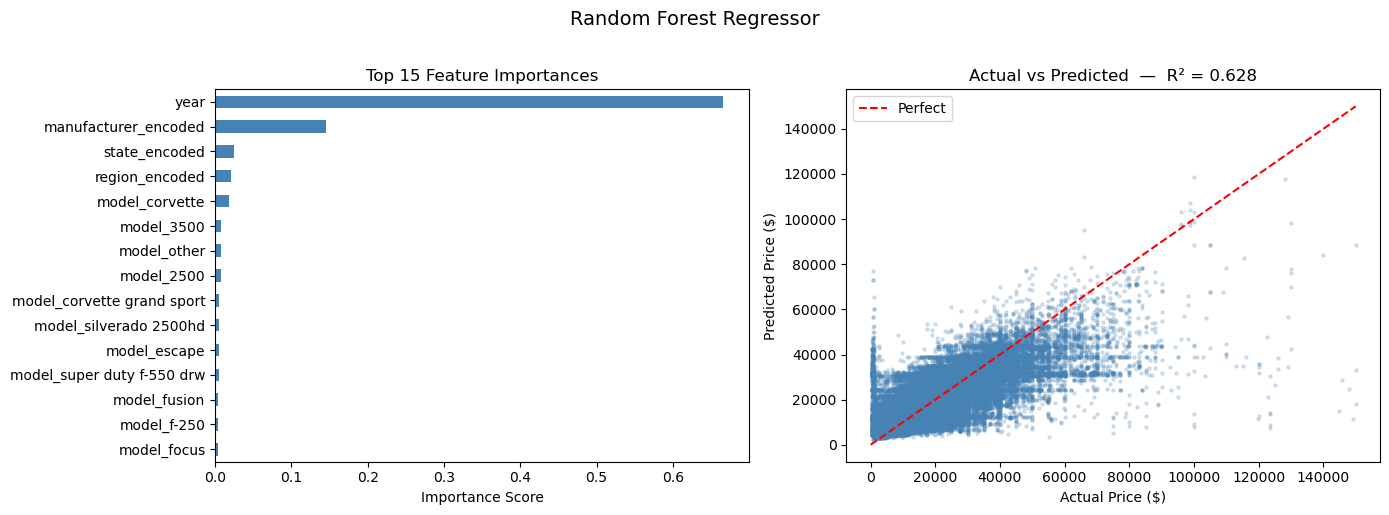

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Top 15 most important features (OHE creates too many to show all)
importances = pd.Series(rf_model.feature_importances_, index=X_rf.columns)
importances.nlargest(15).sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 Feature Importances")
axes[0].set_xlabel("Importance Score")

#Actual vs Predicted
axes[1].scatter(y_rf_test, y_rf_pred, alpha=0.2, s=5, color="steelblue")
axes[1].plot([0, 150_000], [0, 150_000], "r--", linewidth=1.5, label="Perfect")
axes[1].set_xlabel("Actual Price ($)")
axes[1].set_ylabel("Predicted Price ($)")
axes[1].set_title(f"Actual vs Predicted  —  R² = {r2:.3f}")
axes[1].legend()

plt.suptitle("Random Forest Regressor", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Multiple Linear

**Train/Test Split**

In [24]:
X_mlr_train, X_mlr_test = X_rf_train, X_rf_test
y_mlr_train, y_mlr_test = y_rf_train, y_rf_test

**Train model**

In [25]:
mlr_model = LinearRegression(n_jobs=-1)
mlr_model.fit(X_mlr_train, y_mlr_train)

LinearRegression(n_jobs=-1)

**Evaluation**

In [26]:
y_mlr_pred = mlr_model.predict(X_mlr_test)

mlr_mae  = mean_absolute_error(y_mlr_test, y_mlr_pred)
mlr_rmse = np.sqrt(mean_squared_error(y_mlr_test, y_mlr_pred))
mlr_r2   = r2_score(y_mlr_test, y_mlr_pred)

print(f"MAE :  ${mlr_mae:,.0f}")
print(f"RMSE:  ${mlr_rmse:,.0f}")
print(f"R²  :  {mlr_r2:.3f}")

MAE :  $8,282
RMSE:  $11,790
R²  :  0.324


**Visualization**

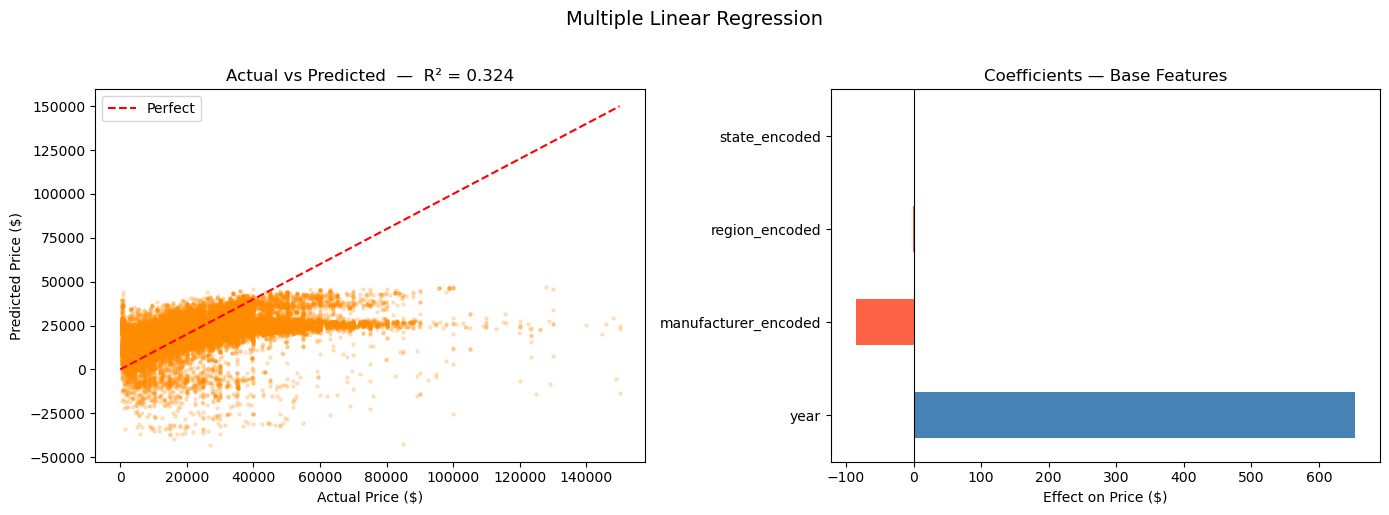

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Actual vs Predicted
axes[0].scatter(y_mlr_test, y_mlr_pred, alpha=0.2, s=5, color="darkorange")
axes[0].plot([0, 150_000], [0, 150_000], "r--", linewidth=1.5, label="Perfect")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title(f"Actual vs Predicted  —  R² = {mlr_r2:.3f}")
axes[0].legend()

#Top 15 largest absolute coefficients (base features only for clarity)
coef_series = pd.Series(mlr_model.coef_, index=X_rf.columns)
coef_series[base_features].plot(
    kind="barh", ax=axes[1],
    color=["steelblue" if v >= 0 else "tomato" for v in coef_series[base_features]]
)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Coefficients — Base Features")
axes[1].set_xlabel("Effect on Price ($)")

plt.suptitle("Multiple Linear Regression", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Model Comparison

In [28]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Multiple Linear Regression"],
    "MAE ($)": [f"{mae:,.0f}", f"{mlr_mae:,.0f}"],
    "RMSE ($)": [f"{rmse:,.0f}", f"{mlr_rmse:,.0f}"],
    "R²": [f"{r2:.3f}", f"{mlr_r2:.3f}"]
})
print(comparison.to_string(index=False))

                     Model MAE ($) RMSE ($)    R²
             Random Forest   5,769    8,747 0.628
Multiple Linear Regression   8,282   11,790 0.324


# Terry Model

In [29]:
# Terry uses: LinearRegression, PolynomialFeatures, RandomForestRegressor, r2_score, StandardScaler, KNeighborsRegressor, train_test_split, sns

In [30]:
vehiclesdfc = vehiclesdfc_clean.copy()

In [31]:
#This is the clean data set

In [32]:
# Next are models: Multiple Linear Regression, Polynomial Regression, and Random Forest regression

In [33]:
# 1. Drop columns that won't help predict price or are too messy (like URLs and IDs)
columns_to_drop = ['id', 'region', 'region_url', 'model', 'state', 'posting_date']
ml_df = vehiclesdfc.drop(columns=columns_to_drop)

# 2. Convert remaining text (like 'manufacturer') into 1s and 0s
ml_df = pd.get_dummies(ml_df, drop_first=True)

# 3. Separate Features (X) and Target (y)
X = ml_df.drop('price', axis=1)
y = ml_df['price']

# 4. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data prepared! Training on {len(X_train)} samples.")

Data prepared! Training on 323216 samples.


In [34]:
# 1. Filter out the "trash" prices and years
# This removes the $0 and $1 entries that are breaking your math
vehicles_filtered = vehiclesdfc[(vehiclesdfc['price'] > 500) & (vehiclesdfc['price'] < 150000)]
vehicles_filtered = vehicles_filtered[(vehicles_filtered['year'] > 1990) & (vehicles_filtered['year'] < 2025)]

# 2. Re-run the preparation
columns_to_drop = ['id', 'region', 'region_url', 'model', 'state', 'posting_date']
ml_df = vehicles_filtered.drop(columns=columns_to_drop)
ml_df = pd.get_dummies(ml_df, drop_first=True)

X = ml_df.drop('price', axis=1)
y = ml_df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Now run your models - you should see positive R-squared values!

In [35]:
# --- 1. Multiple Linear Regression ---
mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)
print(f"Multiple Linear Regression R-squared: {r2_score(y_test, y_pred_mlr):.4f}")

Multiple Linear Regression R-squared: 0.4609


In [36]:
# The reality is that a car loses value as soon as it leaves the lot therefore, linear regression fails to capture this because it tries to draw a straight line through the points, which then causes it to miss the actual car valuation

In [37]:
# 4. Random Forest Regressor (Bonus)
# This builds decision trees and handles non-linear car depreciation beautifully.
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
r2
print(f"Random Forest R-squared: {r2_score(y_test, y_pred_rf):.4f}")

Random Forest R-squared: 0.5544


In [38]:
# 1. Create the Transformer (degree=2 creates Year^2)
poly = PolynomialFeatures(degree=2)

# 2. Transform your original X data into Polynomial data
# This creates the 'X_train_poly' and 'X_test_poly' variables the model is looking for
X_train_poly = poly.fit_transform(X_train[['year']])
X_test_poly = poly.transform(X_test[['year']])

# 3. NOW your existing code will work:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [39]:
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
print(f"Polynomial Regression (Year Only) R-squared: {r2_score(y_test, y_pred_poly):.4f}")

Polynomial Regression (Year Only) R-squared: 0.4288


### I should've scored higher with this model, but due to a lack of information, it scored low 

## Random Forest Regressor is the best model to use out of the three

In [40]:
# --- Tuned Random Forest Regressor ---
# n_estimators: Number of trees (more is usually better but slower)
# max_depth: Limits how complex each tree gets to prevent overfitting
# n_jobs=-1: Uses all your computer's processors to speed it up

rf_tuned = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)
y_pred_tuned = rf_tuned.predict(X_test)

print(f"Original Random Forest R-squared: 0.5724")
print(f"Tuned Random Forest R-squared: {r2_score(y_test, y_pred_tuned):.4f}")

Original Random Forest R-squared: 0.5724
Tuned Random Forest R-squared: 0.5376


In [41]:
# set max_depth to 15, which focuses on the general picture and getting rid of outliers that don't represent the whole market 

In [42]:
df=vehiclesdfc.copy()

In [43]:
# 1. Start fresh from your original data
df = vehiclesdfc.copy()
df.columns = [col.lower().strip() for col in df.columns]

# 2. Filter outliers (The "Clean-Up")
# We remove ultra-cheap cars (usually scams/parts) and ultra-expensive ones
df = df[(df['price'] > 1000) & (df['price'] < 80000)]

# 3. Feature Engineering
df['age'] = 2026 - df['year']

# 4. Use Manufacturer and State (One-Hot Encoding)
# We select the columns that actually impact price
features = ['age', 'manufacturer', 'state']
X = df[features].dropna()
y = df.loc[X.index, 'price'] # Match y to the rows we kept in X

# Convert text (Ford, Tesla, NY, CA) into numbers the model can read
X_encoded = pd.get_dummies(X, columns=['manufacturer', 'state'], drop_first=True)

# 5. Split and Train
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

rf_boosted = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_boosted.fit(X_train, y_train)

# 6. Check the new score
predictions = rf_boosted.predict(X_test)
print(f"New R-squared : {r2_score(y_test, predictions):.4f}")

New R-squared : 0.5932


In [44]:
# 1. SETUP: Prepare the data
df_viz = vehiclesdfc.copy()
df_viz.columns = [col.lower().strip() for col in df_viz.columns]
df_viz = df_viz[(df_viz['price'] > 1000) & (df_viz['price'] < 80000)].dropna(subset=['price', 'year'])
df_viz['age'] = 2026 - df_viz['year']

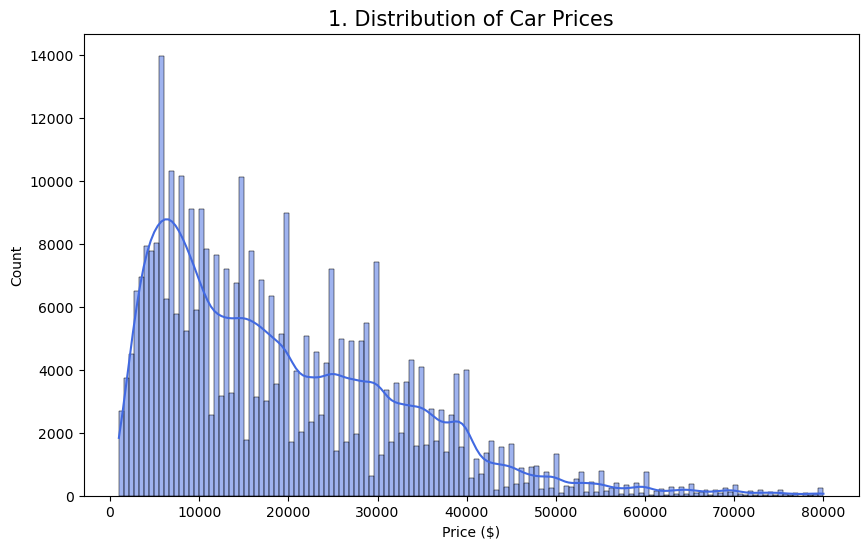

In [45]:
# --- PLOT 1: Price Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df_viz['price'], kde=True, color='royalblue')
plt.title('1. Distribution of Car Prices', fontsize=15)
plt.xlabel('Price ($)')
plt.show()

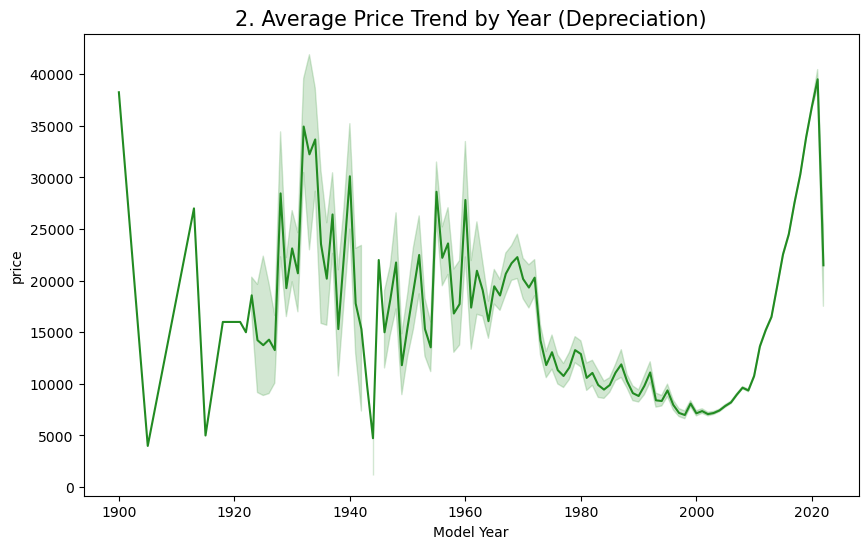

In [46]:
#PLOT 2: Depreciation Curve
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_viz, x='year', y='price', color='forestgreen')
plt.title('2. Average Price Trend by Year (Depreciation)', fontsize=15)
plt.xlabel('Model Year')
plt.show()

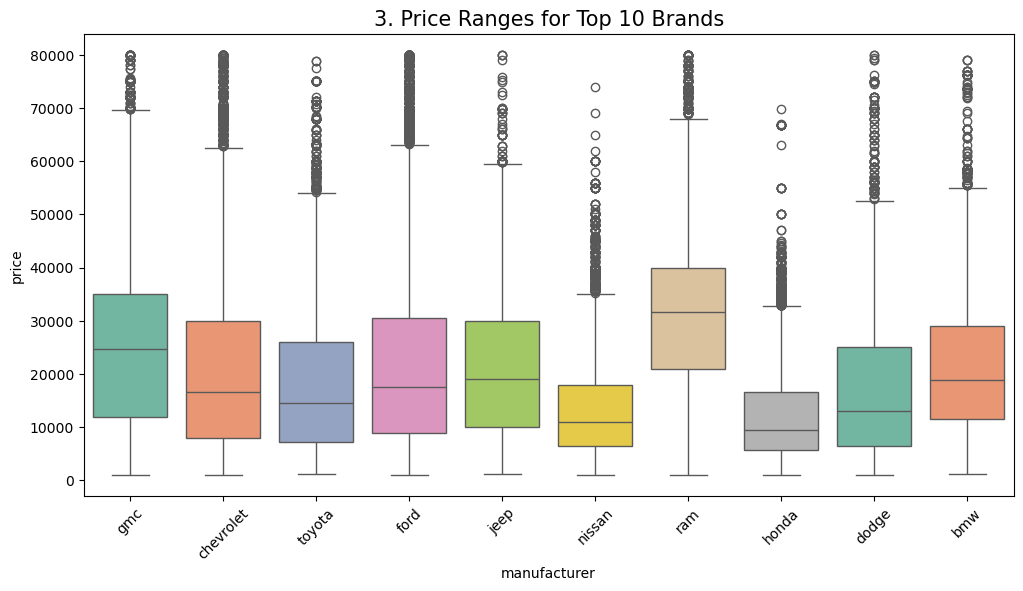

In [47]:
# --- PLOT 3: Top 10 Brands ---
plt.figure(figsize=(12, 6))
top_brands = df_viz['manufacturer'].value_counts().nlargest(10).index
sns.boxplot(data=df_viz[df_viz['manufacturer'].isin(top_brands)], x='manufacturer', y='price', hue='manufacturer', palette='Set2', legend=False)
plt.title('3. Price Ranges for Top 10 Brands', fontsize=15)
plt.xticks(rotation=45)
plt.show()